In [21]:
# 01. 공통 코드
# 공통 처리

# 불필요한 경고 메시지 무시
import warnings
from codecs import xmlcharrefreplace_errors

warnings.filterwarnings("ignore")

# 라이브러리 임폴트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 글꼴 설정
import platform
from matplotlib import rc


if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    rc('font', family='Malgun Gothic')
else:
    rc('font', family='Malgun Gothic')

# 데이터프레임 출력용 함수
from IPython.display import Image

# 숫자 출력 조정
# 넘파이 부동소수점 출력 자리수 설정
np.set_printoptions(suppress=True, precision=4)

# 판다스 부동소수점 출력 자리수 설정
pd.options.display.float_format = '{:,.4f}'.format

# 데이터 프레임 모든 필드 출력
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 그래프 글꼴 크기 설정
plt.rcParams['font.size'] = 14

# 난수 시드
random_seed = 123

In [22]:
# 1. 알고리즘 선택하기
# 실무에서 많이 사용되는 처리 패턴인 분류를 대상으로, 대표적인 알고리즘을 알아보고 선택하는 방법도 알아봄
# 알고리즘을 선택하는 원칙을 알아보고 각 알고리즘이 어떤 데이터 전처리를 필요로 하는지 알아봄.

# 01. 대표적인 분류 알고리즘과 특징
# * 구현 방식에 따른 분류
# 1) 손실 함수 타입
# 로지스틱 회귀 : 시그모이드 함수의 출력을 확률로 취급, 결정 경계는 직선 형태
# 서포트 벡터 머신(커널) : 커널 트릭을 적용해 직선 이외의 결정 경계를 가질 수 있음
# 신경망 : 중간층을 추가하는 방법으로 직선 이외의 결정 경계를 가질 수 있음

# 2) 결정 트리 타입
# 결정 트리 : 특정 필드의 값을 기준으로 그룹을 나누는 과정을 반복
# 랜덤 포레스트 : 학습 데이터의 일부분으로 여러 개의 결정 트리를 만든 다음, 결정 트리 간의 다수결로 결정
# XGBoost : 오분류했던 데이터로 분류 모델을 만들어 정확도를 향상시키는 기법

# 구현 방식은 손실 함수 타입과 결정 트리 방식의 두 가지가 있음
# 전처리 기법 중 데이터 정규화는 손실 함수 타입에서 효과적인 기법이며, 결정 트리 타입에서는 효과를 보기 어려움
# 알고리즘 선택에 따라 필요한 전처리 기법도 달라지기 때문에 모델 내부에 대한 이해없이
# 그냥 활용만 할 생각이더라도 알고리즘의 구현 방식이 무엇인지는 알아둘 필요가 있음

# 1) 손실 함수 타입
# 모델의 구조가 수학적 함수로 결정되 있고, 학습은 함수의 파라미터를 최적화하는 과정에 해당
# 예를 들어 로지스틱 회귀는 1차 함수를 사용해 세 개의 파라미터를 최적화

# 파라미터를 최적화하는 구체적인 방법은 모델의 정확도가 높아질수록 함수값이 작아지는 (모두 정답을 맞히면 0이 되는) 함수인
# '손실 함수'를 정의하고 수학적인 방법을 통해 이 함수의 함수값이 최소가 되는 파라미터 구성


# 2) 결정 트리 타입
# 특정 필드에 역치 threshold를 설정하고 필드 값이 이 역치보다 큰가 작은가를 기준으로 그룹을 나누는 방식
# 어떤 필드의 값이 어떤 역치 값에 따라 어떻게 그룹이 나뉘는가에 대한 규칙을 결정하는 것이 학습 과정이 됨
# 랜덤 포레스트의 XGBoost는 결정 트리를 개량한 알고리즘으로
# 여러 개의 결정 트리를 조합하는 방식으로 모델의 정확도를 향상시킨 모델

# 손실 함수 타입은 입력값이 극단적으로 커지거나 작아지는 경우 알고리즘이 제대로 작동하지 않음
# 이 경우에는 데이터 정규화를 미리 거치는 편이 좋음
# 결정 트리 타입은 단순히 값의 대소 비교만으로 분류가 이루어지기 때문에 정규화처럼 값의 배율을 조정하는 방법은 영향을 미치지 못함


# 02. 사용할 데이터
# 알고리즘을 살펴볼 때 사용한 입력 데이터를 유형별로 세 가지 준비
# 알고리즘의 이해를 위한 입력 데이터라 단순히 2차원 데이터를 사용
# (x, y)와 같은 2차원 데이터를 입력해 O, X를 예측하는 모델이 대상

In [23]:
# 1) 데이터 생성
# 라이브러리 임포트
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles
from sklearn.datasets import make_classification

# make_moons, make_circles: 가상 데이터 받기

# 선형 데이터
x1, y1 = make_classification(n_features=2, n_redundant=0, n_clusters_per_class=1,
                             n_informative=2, n_samples=200, n_classes=2, random_state=random_seed)

# 초승달형 데이터 (선형 분리 불가능)
x2, y2 = make_moons(noise=0.005, random_state=random_seed, n_samples=200)

# 원형 데이터 (선형 분리 불가능)
x3, y3 = make_circles(noise=0.02, n_samples=200,random_state=random_seed)

# 세 가지 데이터를 Datalist 변수에 저장
DataList = [(x1, y1), (x2, y2), (x3, y3)]

# N : 데이터의 가짓수
N = len(DataList)
print(N)

3


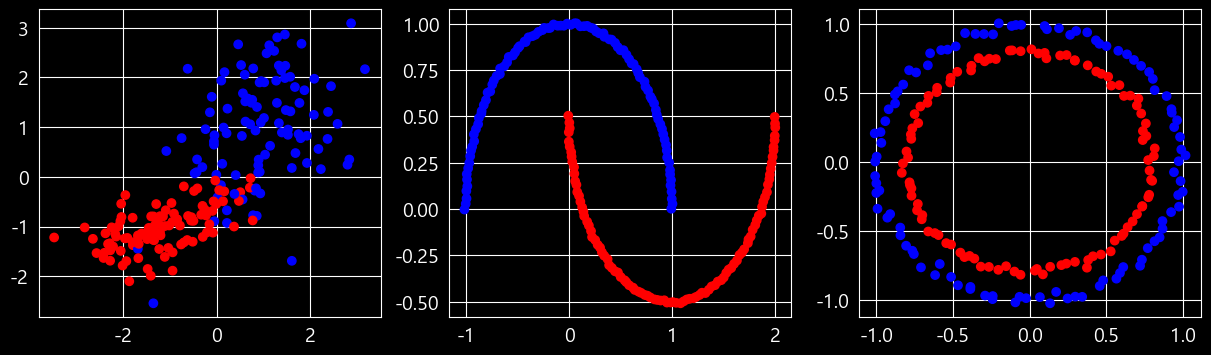

In [24]:
# 2) 데이터의 산점도 그리기
plt.rcParams['axes.unicode_minus'] = False
# 산포도 그리기
plt.figure(figsize=(15,4))

# 컬러맵 정의
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['#0000FF', 'red'])

for i, data in enumerate(DataList):
    x, y = data
    ax = plt.subplot(1, N, i + 1)
    ax.scatter(x[:,0], x[:,1], c=y, cmap=cmap)

In [25]:
# 첫 번째 데이터는 '선형 분리 가능'한 데이터로 직선을 그어 두 그룹을 나눌 수 있는 유형의 데이터
# 다만 경계 부근에 약간 데이터가 섞여 있어서 완전히 깔끔하게 분리되지는 않음
# 각 알고리즘마다 이렇게 섞인 데이터를 어느정도 다르게 처리

# 두 번째 데이터는 직선으로는 그룹을 나눌 수 없는 '선형 분리가 불가능'한 데이터

# 세 번째 데이터는 경계선이 원형이어서 역시 '선형 분리가 불가능'한 데이터

# 실제 업부에서 쓰이는 데이터는 첫 번째 데이터처럼 '선형 분리 가능'한 데이터가 많음
# 하지만 일부는 복잡한 데이터도 분명히 있기 때문에 복잡한 데이터를 처리할 수 있는지도
# 알고리즘을 선택하는 주요한 기준 중 하나

# 정리
# * 세 종류의 예제 데이터는 각각 파란색과 검은색 2차원 점 데이터로 100개로 구성
# * 결과 표시 함수는 100개의 점을 학습용과 검증용으로 50개씩 분할
# * 산점도에 학습 데이터는 X, 검증 데이터는 0으로 구분해 출력
# * 결과 표시 함수 실행 전, 알고리즘은 이미 선택된 상태이며 이 알고리즘을 함수에 인자로 전달
# * 인자로 전달받은 알고리즘을 이용해 '학습', '예측', '평가'를 모두 결과 표시 함수에서 수행
# * 평가 단계에서 학습 데이터와 검증 데이터에 대한 정확도를 따로 계산해 '검증 데이터 : 0.92 학습 데이터 : 0.91'과 같이 출력
# * 각 데이터 점은 해당하는 그룹에 따라 파란색 / 회색으로 나눠 표시
# * 모델의 확신도(confidence)를 음영의 진하기로 표시
# * 진한 부분은 확신도가 높은 부분이고 (확률이 0 또는 1에 가까움), 옅은 부분은 확신도가 낮은 부분(확신도가 0.5에 가까움)
# * 결정 경계가 있는 알고리즘은 결정 경계를 굵은 선으로 표시(일부 알고리즘은 결정 경계를 구할 수 없음)


In [26]:
from sklearn.model_selection import train_test_split

# 결정 경계를 그리는 함수

def plot_boundary(ax, x, y, algorithm):
    '''
    주어진 알고리즘을 사용하여 결정 경계를 시각화하는 함수
    ax : Matplotlib의 서브 플롯(subplot) 객체로, 결정 경계를 그릴 축
    x : 예측 변수
    y : 타겟 변수
    algorithm : 사용할 알고리즘
    '''
    # 1) 입력 데이터를 훈련용, 테스트용 데이터로 분리
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=random_seed)

    # 컬러맵 정의
    from matplotlib.colors import ListedColormap
    cmap1 = plt.cm.bwr
    cmap2 = ListedColormap(['#0000FF', 'red'])

    # 2) 훈령용 데이터로 알고리즘 모델 생성 호, 테스트 데이터를 사용하여 정확도를 평가
    h = 0.005
    algorithm.fit(x_train, y_train)
    score_test = algorithm.score(x_test, y_test) # 테스트 셋으로 정확도 평가
    score_train = algorithm.score(x_train, y_train) # 훈령용 셋으로 정확도 평가

    # 3) 입력 데이터의 범위를 기반으로 결정 경계를 생성
    f1_min = x[:,0].min()- 0.5
    f1_max = x[:,0].max()+ 0.5
    f2_min = x[:,0].min()- 0.5
    f2_max = x[:,0].max()+ 0.5
    f1, f2 = np.meshgrid(np.arange(f1_min, f1_max, h), np.arange(f2_min, f2_max, h))

    # 4) 알고리즘이 결정 함수를 가지고 있는 경우, 확신도를 구하고, 가지고 있지 않은 경우, 예측 확률로 구하고 경계를 그림
    # 확신도 데이터 구함
    if hasattr(algorithm, 'decision_function'):
        Z = algorithm.decision_function(np.c_[f1.ravel(), f2.ravel()])
        Z = Z.reshape(f1.shape)
        ax.contour(f1,f2,Z, levels=[0], linewidths=2)
    else:
        Z = algorithm.predict_proba(np.c_[f1.ravel(), f2.ravel()])[:,1]
        Z = Z.reshape(f1.shape)

    # 5) 테스트 데이터와 훈련 데이터를 산점도로 표시
    # 시각화 처리
    ax.contour(f1, f2, Z, cmap=cmap1, alpha=0.3) # 확신도 그리기
    ax.scatter(x_test[:,0], x_test[:,1], c=y_test, cmap=cmap2)
    ax.scatter(x_train[:,0], x_train[:,1], c=y_train, cmap=cmap2, marker='x')

    # 6) 정확도를 텍스트로 표시
    text = f'검증:{score_test:.2f} 학습:{score_train:.2f}'
    ax.text(f1.max()-0.3, f2.min()+0.3,text, horizontalalignment='right', fontsize=18)

# 산점도와 결정 경계를 그리는 함수
def plot_boundaries(algorithm, DataList):
    plt.figure(figsize=(15,4))
    for i, data in enumerate(DataList):
        x, y = data
        ax = plt.subplot(1, N, i+1)
        plot_boundary(ax, x, y, algorithm)
    plt.show()


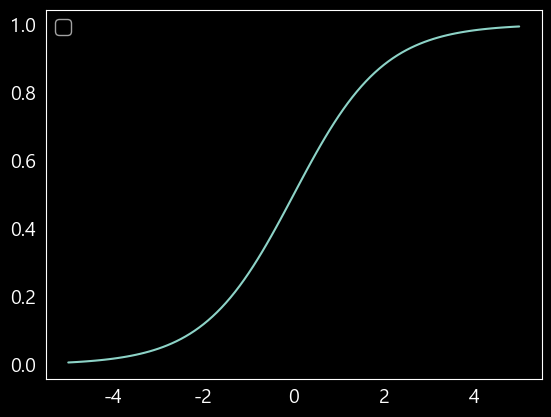

In [27]:
# 03. 로지스틱 회귀
# 단계 1: 입력변수를 1차 함수에 통과시켜 중간값 u를 계산한다.
# 단계 2: 2차 함수의 함수값 u를 '시그모이드 함수'에 통과시킨다.
# 이 함수의 치역은 0부터 1까지의 값이므로 함수값을 확률로 해석할 수 있다.
# 단계 3: 확률값 y의 값이 0.5보다 크면 1로 구분하고, 0.5보다 작으면

# 시그모이드 함수 정의
def sigmoid(x):
    return 1/ (1+np.exp(-x))

# x축 데이터 준비
x = np.linspace(-5, 5, 101)

# y축 데이터 준비
y = sigmoid(x)

# 그래프 작도
plt.plot(x, y)

# 범례 각도
plt.legend()

# 그리드 작도
plt.grid()

# 전체 그래프 출력
plt.show()

In [ ]:
# 시그모이드 함수의 주요 특징
# 1) 함수값이 계속 증가한다.
# 2) 함수값이 0부터 1 사이의 값을 취한다.
# 3) 그래프의 모양이 x=0, y=0.5인 점을 중심으로 점대칭을 이룬다.
# 이러한 성질 덕분에 시그모이드 함수의 함수값은 확률처럼 사용할 수 있음
# 입력 값이 큰 음수라면 확률이 0에 가까워지고, 큰 양수라면 확률이 1에 가까워짐
